# Clinical Characteristics of the Preliminary eICU Clusters

This notebook describes the clinical characteristics of the preliminary
K-Means clustering solution.

The analysis reports:

- The number and percentage of ICU stays in each cluster
- The median and interquartile range of every clustering variable
- The mean and standard deviation of every clustering variable
- The variables that most strongly distinguish each cluster
- A brief descriptive interpretation of each cluster
- Standardized cluster-profile figures
- Exploratory comparisons of mortality and length of stay

The clinical outcome comparisons are descriptive and exploratory. The
outcomes were not used to create the clusters, and differences between
clusters should not be interpreted as evidence that cluster membership
causes an outcome.

### Import Required Libraries

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

#### Explanation :
These libraries are used for:

- Loading and merging the datasets
- Calculating cluster-level statistics
- Ranking distinguishing variables
- Creating tables
- Producing heatmaps, bar charts and boxplots
- Saving all results

### Locate the Project Root Folder

In [2]:
# Get the folder from which the notebook is running
CURRENT_DIR = Path.cwd().resolve()


# Identify the project root folder
if (CURRENT_DIR / "data").exists() and (CURRENT_DIR / "notebooks").exists():

    ROOT_DIR = CURRENT_DIR

elif CURRENT_DIR.name == "module_2" and CURRENT_DIR.parent.name == "notebooks":

    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":

    ROOT_DIR = CURRENT_DIR.parent

else:

    raise FileNotFoundError(
        "The project root folder could not be identified. "
        "Run the notebook from the project root, notebooks, "
        "or notebooks/module_2 folder."
    )


print("Project root folder:")
print(ROOT_DIR)

Project root folder:
C:\Users\samsa\Documents\Capstone Project\Project


#### Explanation :
This code allows the notebook to run from:
```
project_root/notebooks/module_2
```

### Define the Input and Output Paths

In [3]:
# Input files
ANALYTIC_DATASET_PATH = (
    ROOT_DIR
    / "data"
    / "analytic_dataset.csv"
)

CLUSTER_ASSIGNMENTS_PATH = (
    ROOT_DIR
    / "results"
    / "kmeans_eicu"
    / "preliminary_cluster_assignments.csv"
)

STANDARDIZED_CENTERS_PATH = (
    ROOT_DIR
    / "results"
    / "kmeans_eicu"
    / "preliminary_cluster_centers_standardized.csv"
)

PROCESSED_DATA_DIR = (
    ROOT_DIR
    / "data"
    / "processed"
)


# Main output folders
PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "cluster_characteristics"
)

RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "cluster_characteristics"
)


# Plot subfolders
PROFILE_PLOTS_DIR = (
    PLOTS_DIR
    / "profiles"
)

DISTRIBUTION_PLOTS_DIR = (
    PLOTS_DIR
    / "distributions"
)

CLUSTER_SIZE_PLOTS_DIR = (
    PLOTS_DIR
    / "cluster_sizes"
)

OUTCOME_PLOTS_DIR = (
    PLOTS_DIR
    / "outcomes"
)


# Create output folders
output_folders = [
    PLOTS_DIR,
    RESULTS_DIR,
    PROFILE_PLOTS_DIR,
    DISTRIBUTION_PLOTS_DIR,
    CLUSTER_SIZE_PLOTS_DIR,
    OUTCOME_PLOTS_DIR,
]


for folder in output_folders:

    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=" * 100)
print("INPUT AND OUTPUT PATHS")
print("=" * 100)

print(f"Analytic dataset       : {ANALYTIC_DATASET_PATH}")
print(f"Cluster assignments    : {CLUSTER_ASSIGNMENTS_PATH}")
print(f"Standardized centers   : {STANDARDIZED_CENTERS_PATH}")
print(f"Processed eICU tables  : {PROCESSED_DATA_DIR}")
print(f"Plot output folder     : {PLOTS_DIR}")
print(f"Result output folder   : {RESULTS_DIR}")

print("=" * 100)

INPUT AND OUTPUT PATHS
Analytic dataset       : C:\Users\samsa\Documents\Capstone Project\Project\data\analytic_dataset.csv
Cluster assignments    : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\preliminary_cluster_assignments.csv
Standardized centers   : C:\Users\samsa\Documents\Capstone Project\Project\results\kmeans_eicu\preliminary_cluster_centers_standardized.csv
Processed eICU tables  : C:\Users\samsa\Documents\Capstone Project\Project\data\processed
Plot output folder     : C:\Users\samsa\Documents\Capstone Project\Project\plots\cluster_characteristics
Result output folder   : C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics


#### Explanation :
The notebook uses:

- `analytic_dataset.csv` for clinical values
- `preliminary_cluster_assignments.csv` for cluster labels
- `preliminary_cluster_centers_standardized.csv` for identifying the strongest distinguishing variables

All new tables are saved inside:
```
results/cluster_characteristics/
```
All new plots are saved inside:
```
plots/cluster_characteristics/
```

### Define the Clinical Variables

In [4]:
ID_COLUMN = "patientunitstayid"


FEATURES = [
    "age",
    "heart_rate",
    "mean_arterial_pressure",
    "respiratory_rate",
    "oxygen_saturation",
    "temperature",
    "gcs",
    "urine_output",
    "wbc",
    "hemoglobin",
    "platelets",
    "sodium",
    "potassium",
    "bicarbonate",
    "creatinine",
    "glucose",
    "lactate",
    "total_bilirubin",
    "albumin",
    "inr",
]


# Clear names used in tables and figures
FEATURE_LABELS = {
    "age": "Age",
    "heart_rate": "Heart rate",
    "mean_arterial_pressure": "Mean arterial pressure",
    "respiratory_rate": "Respiratory rate",
    "oxygen_saturation": "Oxygen saturation",
    "temperature": "Temperature",
    "gcs": "Glasgow Coma Scale",
    "urine_output": "Urine output",
    "wbc": "White blood cell count",
    "hemoglobin": "Hemoglobin",
    "platelets": "Platelet count",
    "sodium": "Sodium",
    "potassium": "Potassium",
    "bicarbonate": "Bicarbonate",
    "creatinine": "Creatinine",
    "glucose": "Glucose",
    "lactate": "Lactate",
    "total_bilirubin": "Total bilirubin",
    "albumin": "Albumin",
    "inr": "International normalized ratio",
}


print(f"Number of clustering variables: {len(FEATURES)}")

for number, feature in enumerate(FEATURES, start=1):

    print(
        f"{number:2d}. "
        f"{FEATURE_LABELS[feature]}"
    )

Number of clustering variables: 20
 1. Age
 2. Heart rate
 3. Mean arterial pressure
 4. Respiratory rate
 5. Oxygen saturation
 6. Temperature
 7. Glasgow Coma Scale
 8. Urine output
 9. White blood cell count
10. Hemoglobin
11. Platelet count
12. Sodium
13. Potassium
14. Bicarbonate
15. Creatinine
16. Glucose
17. Lactate
18. Total bilirubin
19. Albumin
20. International normalized ratio


#### Explanation :
These are the same $20$ clinical variables used to create the KMeans clusters.  
The feature labels provide clearer names for presentation tables and figures.

### Define the Analysis Settings

In [5]:
# Number of strongest variables reported for each cluster
NUMBER_OF_DISTINGUISHING_VARIABLES = 5


# Number of variables selected for individual boxplots
NUMBER_OF_BOXPLOT_VARIABLES = 5


# Fixed seed used when sampling observations for figures
PLOT_RANDOM_SEED = 42


# Maximum number of observations shown in large distribution plots
PLOT_SAMPLE_SIZE = 20_000


print("=" * 75)
print("CLUSTER CHARACTERIZATION SETTINGS")
print("=" * 75)

print(
    "Strongest variables per cluster :",
    NUMBER_OF_DISTINGUISHING_VARIABLES,
)

print(
    "Variables used for boxplots     :",
    NUMBER_OF_BOXPLOT_VARIABLES,
)

print(
    "Maximum plotting sample size    :",
    f"{PLOT_SAMPLE_SIZE:,}",
)

print("=" * 75)

CLUSTER CHARACTERIZATION SETTINGS
Strongest variables per cluster : 5
Variables used for boxplots     : 5
Maximum plotting sample size    : 20,000


#### Explanation :
Five distinguishing variables will be reported for each cluster.

For large distribution figures, a fixed sample of up to $20,000$ ICU stays is used. This keeps figures readable while making the sampling reproducible.

All statistical tables are calculated using the complete dataset.

### Load the Analytic Dataset

In [6]:
analytic_data = pd.read_csv(
    ANALYTIC_DATASET_PATH
)


print(
    "Analytic dataset shape:",
    analytic_data.shape,
)


analytic_data.head()

Analytic dataset shape: (123400, 21)


,patientunitstayid,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141168,70.0,125.052830,66.200000,18.975524,86.741935,37.120628,14.0,1400.0,9.8,...,209.0,139.0,4.0,26.0,1.95,131.0,1.7,2.60,3.1,1.7
1,141179,52.0,92.295139,82.466667,18.975524,98.747253,37.120628,9.0,1900.0,10.8,...,191.0,146.0,3.6,22.0,0.70,54.0,1.7,0.62,2.9,1.3
2,141194,68.0,86.860627,61.224138,23.193662,98.589474,37.120628,15.0,1855.0,14.1,...,233.0,135.0,4.0,19.0,2.51,165.0,1.3,0.40,2.3,1.3
3,141196,71.0,82.305147,94.571429,24.114815,95.509434,37.120628,15.0,650.0,26.2,...,453.0,135.0,4.1,30.0,0.80,144.0,1.7,0.30,2.5,1.3
4,141203,77.0,91.538194,75.343511,18.713208,98.102473,37.120628,14.0,1400.0,12.7,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.50,1.6,1.3


#### Explanation :
The analytic dataset contains :
- One row per ICU stay
- One ICU stay identifier
- Twenty clustering variables
- Imputed clinical values in understandable units

The cluster-characteristics table will therefore describe the values that were used to construct the standardized clustering matrix.

### Load the Preliminary Cluster Assignments

In [7]:
cluster_assignments = pd.read_csv(
    CLUSTER_ASSIGNMENTS_PATH
)


print(
    "Cluster assignment shape:",
    cluster_assignments.shape,
)


cluster_assignments.head()

Cluster assignment shape: (123400, 4)


,clustering_row_number,patientunitstayid,selected_k,cluster
0,0,141168,2,1
1,1,141179,2,0
2,2,141194,2,1
3,3,141196,2,0
4,4,141203,2,0


#### Explanation :
This file contains the preliminary cluster label assigned to each ICU stay.

The selected value of `k` will be read directly from this file.

### Load the Standardized Cluster Centers

In [8]:
standardized_centers = pd.read_csv(
    STANDARDIZED_CENTERS_PATH
)


print(
    "Standardized cluster-center shape:",
    standardized_centers.shape,
)


standardized_centers.head()

Standardized cluster-center shape: (2, 22)


,selected_k,cluster,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,2,0,-0.057303,-0.140019,0.177966,-0.088087,-0.028651,0.038265,0.104153,0.178186,...,0.122609,0.052519,-0.200336,0.230308,-0.360364,-0.092173,-0.184992,-0.172868,0.202794,-0.195668
1,2,1,0.140942,0.344389,-0.437722,0.216658,0.070469,-0.094117,-0.256173,-0.438263,...,-0.301569,-0.129175,0.492744,-0.566464,0.886346,0.226708,0.455004,0.425183,-0.498789,0.481263


#### Explanation :
The standardized cluster centers show whether each cluster has values above or below the overall cohort average.

They are used to identify the variables that most strongly distinguish each cluster.

### Check the Input Files

In [9]:
# Check the analytic dataset
required_analytic_columns = [
    ID_COLUMN,
    *FEATURES,
]


missing_analytic_columns = [
    column
    for column in required_analytic_columns
    if column not in analytic_data.columns
]


assert not missing_analytic_columns, (
    "The analytic dataset is missing the following columns: "
    f"{missing_analytic_columns}"
)


# Check the assignment dataset
required_assignment_columns = [
    ID_COLUMN,
    "selected_k",
    "cluster",
]


missing_assignment_columns = [
    column
    for column in required_assignment_columns
    if column not in cluster_assignments.columns
]


assert not missing_assignment_columns, (
    "The assignment dataset is missing the following columns: "
    f"{missing_assignment_columns}"
)


# Check the standardized centers
required_center_columns = [
    "cluster",
    *FEATURES,
]


missing_center_columns = [
    column
    for column in required_center_columns
    if column not in standardized_centers.columns
]


assert not missing_center_columns, (
    "The standardized cluster-center file is missing: "
    f"{missing_center_columns}"
)


# Check duplicate ICU stay identifiers
assert analytic_data[ID_COLUMN].duplicated().sum() == 0, (
    "Duplicate ICU stay identifiers exist in the analytic dataset."
)


assert cluster_assignments[ID_COLUMN].duplicated().sum() == 0, (
    "Duplicate ICU stay identifiers exist in the assignment file."
)


# Confirm only one selected value of k is present
selected_k_values = (
    cluster_assignments[
        "selected_k"
    ]
    .dropna()
    .unique()
)


assert len(selected_k_values) == 1, (
    "The assignment file contains more than one selected value of k."
)


SELECTED_K = int(
    selected_k_values[0]
)


# Confirm the expected number of clusters
assert (
    cluster_assignments[
        "cluster"
    ].nunique()
    == SELECTED_K
), (
    "The number of cluster labels does not match the selected k."
)


# Check the standardized centers
assert standardized_centers["cluster"].nunique() == SELECTED_K, (
    "The number of standardized centers does not match the selected k."
)


print("=" * 75)
print("ALL INPUT CHECKS PASSED")
print("=" * 75)

print(f"Selected preliminary k : {SELECTED_K}")
print(
    "Number of ICU stays    :",
    f"{len(cluster_assignments):,}",
)
print(
    "Number of clusters     :",
    cluster_assignments["cluster"].nunique(),
)

print("=" * 75)

ALL INPUT CHECKS PASSED
Selected preliminary k : 2
Number of ICU stays    : 123,400
Number of clusters     : 2


#### Explanation :
This section confirms that :
- All required columns are present
- ICU stay identifiers are unique
- Only one selected value of `k` is present
- The number of cluster labels matches the selected model
- The number of cluster centers matches the selected model

### Merge the Clinical Data with the Cluster Labels

In [10]:
selected_cluster_data = analytic_data.merge(
    cluster_assignments[
        [
            ID_COLUMN,
            "selected_k",
            "cluster",
        ]
    ],
    on=ID_COLUMN,
    how="inner",
    validate="one_to_one",
)


# Put the identifier and cluster information first
selected_cluster_data = selected_cluster_data[
    [
        ID_COLUMN,
        "selected_k",
        "cluster",
        *FEATURES,
    ]
].copy()


# Sort by cluster and ICU stay identifier
selected_cluster_data = selected_cluster_data.sort_values(
    [
        "cluster",
        ID_COLUMN,
    ]
).reset_index(drop=True)


assert len(selected_cluster_data) == len(cluster_assignments), (
    "Some cluster assignments could not be linked to "
    "the analytic dataset."
)


selected_cluster_data.to_csv(
    RESULTS_DIR
    / "selected_cluster_dataset.csv",
    index=False,
)


print(
    "Merged cluster dataset shape:",
    selected_cluster_data.shape,
)


selected_cluster_data.head()

Merged cluster dataset shape: (123400, 23)


,patientunitstayid,selected_k,cluster,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,141179,2,0,52.0,92.295139,82.466667,18.975524,98.747253,37.120628,9.0,...,191.0,146.0,3.6,22.0,0.70,54.0,1.7,0.62,2.9,1.3
1,141196,2,0,71.0,82.305147,94.571429,24.114815,95.509434,37.120628,15.0,...,453.0,135.0,4.1,30.0,0.80,144.0,1.7,0.30,2.5,1.3
2,141203,2,0,77.0,91.538194,75.343511,18.713208,98.102473,37.120628,14.0,...,557.0,145.0,4.2,25.0,0.56,145.0,3.5,0.50,1.6,1.3
3,141244,2,0,59.0,103.283737,70.571429,14.276817,95.388889,37.120628,15.0,...,84.0,142.0,3.8,27.0,0.65,121.0,1.7,0.62,2.9,1.3
4,141265,2,0,67.0,95.816794,97.601852,19.918605,94.496124,37.120628,15.0,...,159.0,137.0,3.7,27.0,0.71,156.0,1.7,0.62,2.9,1.1


#### Explanation :
This creates one dataset containing :
- ICU stay identifier
- Selected value of `k`
- Cluster label
- Twenty clinical variables

It is saved as :
```
results/cluster_characteristics/selected_cluster_dataset.csv
```

### Calculate the Number and Percentage of ICU Stays

In [11]:
total_icu_stays = len(
    selected_cluster_data
)


cluster_size_summary = (
    selected_cluster_data[
        "cluster"
    ]
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(
        name="icu_stay_count"
    )
)


cluster_size_summary[
    "icu_stay_percent"
] = (
    cluster_size_summary[
        "icu_stay_count"
    ]
    / total_icu_stays
    * 100
)


cluster_size_summary[
    "selected_k"
] = SELECTED_K


cluster_size_summary = cluster_size_summary[
    [
        "selected_k",
        "cluster",
        "icu_stay_count",
        "icu_stay_percent",
    ]
]


cluster_size_summary.to_csv(
    RESULTS_DIR
    / "cluster_size_summary.csv",
    index=False,
)


cluster_size_summary

,selected_k,cluster,icu_stay_count,icu_stay_percent
0,2,0,87828,71.17342
1,2,1,35572,28.82658


#### Explanation :
This table reports :
- The number of ICU stays in each cluster
- The percentage of the complete cohort in each cluster

It is the first required part of the cluster-characteristics deliverable.

### Create the Cluster Size Figure

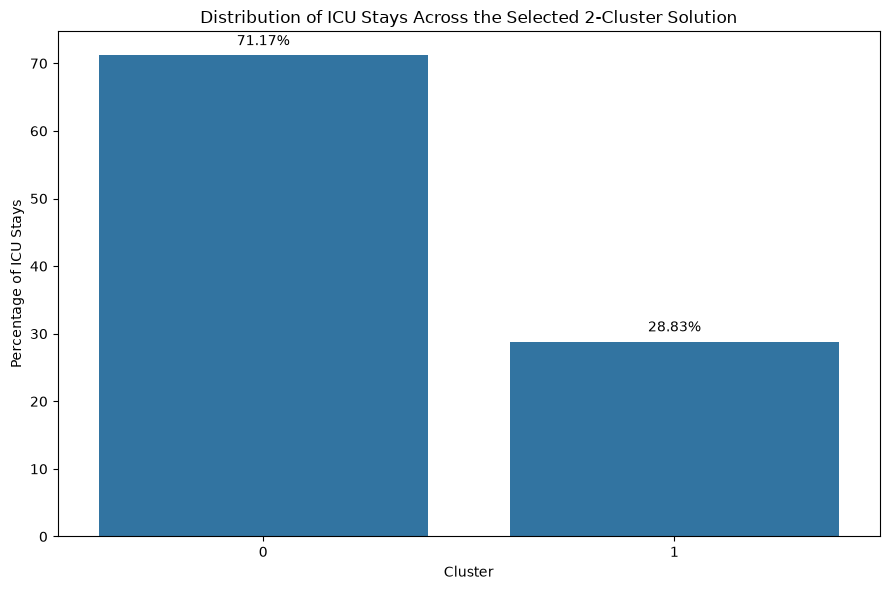

In [12]:
plt.figure(figsize=(9, 6))


cluster_size_plot = sns.barplot(
    data=cluster_size_summary,
    x="cluster",
    y="icu_stay_percent",
)


# Add the percentage above every bar
for bar, percent in zip(
    cluster_size_plot.patches,
    cluster_size_summary[
        "icu_stay_percent"
    ],
):

    cluster_size_plot.annotate(
        f"{percent:.2f}%",
        (
            bar.get_x()
            + bar.get_width() / 2,
            bar.get_height(),
        ),
        ha="center",
        va="bottom",
        xytext=(0, 5),
        textcoords="offset points",
    )


plt.title(
    f"Distribution of ICU Stays Across the "
    f"Selected {SELECTED_K}-Cluster Solution"
)

plt.xlabel(
    "Cluster"
)

plt.ylabel(
    "Percentage of ICU Stays"
)

plt.tight_layout()


plt.savefig(
    CLUSTER_SIZE_PLOTS_DIR
    / "selected_cluster_sizes.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This figure shows how the cohort is distributed across the selected clusters.

It provides a clear visual summary of whether the preliminary solution contains balanced or uneven cluster sizes.

### Calculate Detailed Clinical Statistics

In [13]:
cluster_characteristics_rows = []


cluster_numbers = sorted(
    selected_cluster_data[
        "cluster"
    ].unique()
)


for cluster_number in cluster_numbers:

    cluster_data = selected_cluster_data[
        selected_cluster_data[
            "cluster"
        ]
        == cluster_number
    ]


    for feature in FEATURES:

        feature_values = cluster_data[
            feature
        ].dropna()


        first_quartile = (
            feature_values.quantile(0.25)
        )

        median_value = (
            feature_values.median()
        )

        third_quartile = (
            feature_values.quantile(0.75)
        )


        cluster_characteristics_rows.append(
            {
                "selected_k": SELECTED_K,
                "cluster": cluster_number,
                "variable": feature,
                "variable_label": (
                    FEATURE_LABELS[feature]
                ),
                "available_count": (
                    feature_values.count()
                ),
                "mean": (
                    feature_values.mean()
                ),
                "standard_deviation": (
                    feature_values.std()
                ),
                "median": median_value,
                "first_quartile": (
                    first_quartile
                ),
                "third_quartile": (
                    third_quartile
                ),
                "interquartile_range": (
                    third_quartile
                    - first_quartile
                ),
                "minimum": (
                    feature_values.min()
                ),
                "maximum": (
                    feature_values.max()
                ),
            }
        )


cluster_characteristics_long = pd.DataFrame(
    cluster_characteristics_rows
)


cluster_characteristics_long.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_long_format.csv",
    index=False,
)


cluster_characteristics_long.head(10)

,selected_k,cluster,variable,variable_label,available_count,mean,standard_deviation,median,first_quartile,third_quartile,interquartile_range,minimum,maximum
0,2,0,age,Age,87828,62.905008,16.779937,65.000000,53.000000,76.000000,23.000000,18.000000,90.000000
1,2,0,heart_rate,Heart rate,87828,83.162867,15.367437,82.362523,72.115688,93.031277,20.915589,24.000000,165.881119
2,2,0,mean_arterial_pressure,Mean arterial pressure,87828,83.193252,13.143528,81.555556,73.727273,91.298246,17.570973,26.000000,163.000000
3,2,0,respiratory_rate,Respiratory rate,87828,19.276732,4.294860,18.975524,16.443756,21.252708,4.808952,4.000000,80.000000
4,2,0,oxygen_saturation,Oxygen saturation,87828,96.803908,2.039406,97.031579,95.538462,98.327418,2.788956,55.000000,100.000000
5,2,0,temperature,Temperature,87828,37.116898,0.289718,37.120628,37.120628,37.120628,0.000000,28.707143,41.066667
6,2,0,gcs,Glasgow Coma Scale,87828,12.915221,3.106929,14.000000,13.000000,15.000000,2.000000,3.000000,15.000000
7,2,0,urine_output,Urine output,87828,1769.185865,1183.528037,1400.000000,1160.000000,2135.250000,975.250000,0.000000,19850.000000
8,2,0,wbc,White blood cell count,87828,11.385347,5.704920,10.700000,7.800000,13.600000,5.800000,0.100000,150.700000
9,2,0,hemoglobin,Hemoglobin,87828,11.405969,2.139133,11.300000,10.000000,12.900000,2.900000,2.600000,23.000000


#### Explanation :
For every clinical variable in every cluster, the code calculates:

- Available count
- Mean
- Standard deviation
- Median
- First quartile
- Third quartile
- Interquartile range
- Minimum
- Maximum

The long-format table preserves all detailed summary values.

### Create the Main Median and Interquartile Range Table

In [14]:
def format_median_iqr(
    median_value,
    first_quartile,
    third_quartile,
):
    """
    Format a clinical variable as:
    Median [first quartile–third quartile]
    """

    return (
        f"{median_value:.2f} "
        f"[{first_quartile:.2f}–"
        f"{third_quartile:.2f}]"
    )

#### Explanation :
This function creates clear table values such as:
```
1.20 [0.80–2.10]
```
This means :
- Median = $1.20$
- First Quartile = $0.80$
- Third Quartile = $2.10$

In [15]:
main_table_rows = []


# Add the cluster-size row
cluster_size_row = {
    "Characteristic": "ICU stays, n (%)"
}


for cluster_number in cluster_numbers:

    current_size = cluster_size_summary[
        cluster_size_summary[
            "cluster"
        ]
        == cluster_number
    ].iloc[0]


    cluster_size_row[
        f"Cluster {cluster_number}"
    ] = (
        f"{int(current_size['icu_stay_count']):,} "
        f"({current_size['icu_stay_percent']:.2f}%)"
    )


main_table_rows.append(
    cluster_size_row
)


# Add every clinical variable
for feature in FEATURES:

    variable_row = {
        "Characteristic": (
            f"{FEATURE_LABELS[feature]}, "
            "median [IQR]"
        )
    }


    for cluster_number in cluster_numbers:

        current_summary = (
            cluster_characteristics_long[
                (
                    cluster_characteristics_long[
                        "cluster"
                    ]
                    == cluster_number
                )
                &
                (
                    cluster_characteristics_long[
                        "variable"
                    ]
                    == feature
                )
            ]
            .iloc[0]
        )


        variable_row[
            f"Cluster {cluster_number}"
        ] = format_median_iqr(
            current_summary["median"],
            current_summary[
                "first_quartile"
            ],
            current_summary[
                "third_quartile"
            ],
        )


    main_table_rows.append(
        variable_row
    )


cluster_characteristics_table = pd.DataFrame(
    main_table_rows
)


cluster_characteristics_table.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_table.csv",
    index=False,
)


cluster_characteristics_table

,Characteristic,Cluster 0,Cluster 1
0,"ICU stays, n (%)","87,828 (71.17%)","35,572 (28.83%)"
1,"Age, median [IQR]",65.00 [53.00–76.00],68.00 [57.00–78.00]
2,"Heart rate, median [IQR]",82.36 [72.12–93.03],90.09 [78.98–102.72]
3,"Mean arterial pressure, median [IQR]",81.56 [73.73–91.30],73.34 [66.80–81.24]
4,"Respiratory rate, median [IQR]",18.98 [16.44–21.25],19.62 [17.35–23.39]
5,"Oxygen saturation, median [IQR]",97.03 [95.54–98.33],97.36 [95.82–98.75]
6,"Temperature, median [IQR]",37.12 [37.12–37.12],37.12 [37.12–37.12]
7,"Glasgow Coma Scale, median [IQR]",14.00 [13.00–15.00],14.00 [9.00–15.00]
8,"Urine output, median [IQR]",1400.00 [1160.00–2135.25],1400.00 [550.00–1400.00]
9,"White blood cell count, median [IQR]",10.70 [7.80–13.60],11.90 [8.50–17.60]


#### Explanation :
This is the primary required deliverable.
It contains :
- ICU stay count and percentage
- Median and interquartile range for all $20$ clustering variables
- One column for every cluster

This table is saved as :
```
results/cluster_characteristics/cluster_characteristics_table.csv
```

### Create a Supplementary Mean and Standard Deviation Table

In [16]:
def format_mean_standard_deviation(
    mean_value,
    standard_deviation,
):
    """
    Format a clinical variable as:
    Mean (standard deviation)
    """

    return (
        f"{mean_value:.2f} "
        f"({standard_deviation:.2f})"
    )

#### Explanation :
This function formats results such as:

$64.30 (15.20)$

This represents:

Mean = $64.30$
Standard deviation = $15.20$

In [17]:
mean_sd_table_rows = []


for feature in FEATURES:

    variable_row = {
        "Characteristic": (
            f"{FEATURE_LABELS[feature]}, "
            "mean (SD)"
        )
    }


    for cluster_number in cluster_numbers:

        current_summary = (
            cluster_characteristics_long[
                (
                    cluster_characteristics_long[
                        "cluster"
                    ]
                    == cluster_number
                )
                &
                (
                    cluster_characteristics_long[
                        "variable"
                    ]
                    == feature
                )
            ]
            .iloc[0]
        )


        variable_row[
            f"Cluster {cluster_number}"
        ] = format_mean_standard_deviation(
            current_summary["mean"],
            current_summary[
                "standard_deviation"
            ],
        )


    mean_sd_table_rows.append(
        variable_row
    )


cluster_mean_sd_table = pd.DataFrame(
    mean_sd_table_rows
)


cluster_mean_sd_table.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_mean_sd.csv",
    index=False,
)


cluster_mean_sd_table

,Characteristic,Cluster 0,Cluster 1
0,"Age, mean (SD)",62.91 (16.78),66.15 (15.61)
1,"Heart rate, mean (SD)",83.16 (15.37),91.06 (17.16)
2,"Mean arterial pressure, mean (SD)",83.19 (13.14),74.97 (12.14)
3,"Respiratory rate, mean (SD)",19.28 (4.29),20.67 (5.05)
4,"Oxygen saturation, mean (SD)",96.80 (2.04),97.02 (2.44)
5,"Temperature, mean (SD)",37.12 (0.29),37.07 (0.53)
6,"Glasgow Coma Scale, mean (SD)",12.92 (3.11),11.69 (3.96)
7,"Urine output, mean (SD)",1769.19 (1183.53),1253.76 (1064.56)
8,"White blood cell count, mean (SD)",11.39 (5.70),14.28 (10.30)
9,"Hemoglobin, mean (SD)",11.41 (2.14),9.82 (2.12)


#### Explanation :
The main table uses median and interquartile range because many ICU variables are skewed.

This supplementary table reports mean and standard deviation for completeness.

### Prepare the Standardized Cluster Centers

In [18]:
# Keep only the cluster number and the 20 features
standardized_centers_clean = (
    standardized_centers[
        [
            "cluster",
            *FEATURES,
        ]
    ]
    .copy()
)


standardized_centers_clean[
    "cluster"
] = (
    standardized_centers_clean[
        "cluster"
    ].astype(int)
)


standardized_centers_clean = (
    standardized_centers_clean
    .sort_values("cluster")
    .reset_index(drop=True)
)


standardized_centers_clean

,cluster,age,heart_rate,mean_arterial_pressure,respiratory_rate,oxygen_saturation,temperature,gcs,urine_output,wbc,...,platelets,sodium,potassium,bicarbonate,creatinine,glucose,lactate,total_bilirubin,albumin,inr
0,0,-0.057303,-0.140019,0.177966,-0.088087,-0.028651,0.038265,0.104153,0.178186,-0.079284,...,0.122609,0.052519,-0.200336,0.230308,-0.360364,-0.092173,-0.184992,-0.172868,0.202794,-0.195668
1,1,0.140942,0.344389,-0.437722,0.216658,0.070469,-0.094117,-0.256173,-0.438263,0.195006,...,-0.301569,-0.129175,0.492744,-0.566464,0.886346,0.226708,0.455004,0.425183,-0.498789,0.481263


#### Explanation :
The standardized centers are used to measure how far each cluster is from the overall cohort average.

A standardized center :
- Above zero means the cluster is above the cohort average
- Below zero means the cluster is below the cohort average
- Near zero means the cluster is close to the cohort average

### Identify the Strongest Distinguishing Variables

In [19]:
standardized_centers_long = (
    standardized_centers_clean
    .melt(
        id_vars="cluster",
        value_vars=FEATURES,
        var_name="variable",
        value_name="standardized_center",
    )
)


standardized_centers_long[
    "variable_label"
] = (
    standardized_centers_long[
        "variable"
    ].map(FEATURE_LABELS)
)


standardized_centers_long[
    "absolute_standardized_center"
] = (
    standardized_centers_long[
        "standardized_center"
    ].abs()
)


standardized_centers_long[
    "direction"
] = np.where(
    standardized_centers_long[
        "standardized_center"
    ]
    >= 0,
    "Higher than cohort average",
    "Lower than cohort average",
)


# Rank variables separately within every cluster
standardized_centers_long[
    "distinguishing_rank"
] = (
    standardized_centers_long
    .groupby("cluster")[
        "absolute_standardized_center"
    ]
    .rank(
        ascending=False,
        method="first",
    )
)


cluster_distinguishing_variables = (
    standardized_centers_long[
        standardized_centers_long[
            "distinguishing_rank"
        ]
        <= NUMBER_OF_DISTINGUISHING_VARIABLES
    ]
    .sort_values(
        [
            "cluster",
            "distinguishing_rank",
        ]
    )
    .reset_index(drop=True)
)


cluster_distinguishing_variables.to_csv(
    RESULTS_DIR
    / "cluster_distinguishing_variables.csv",
    index=False,
)


cluster_distinguishing_variables

,cluster,variable,standardized_center,variable_label,absolute_standardized_center,direction,distinguishing_rank
0,0,creatinine,-0.360364,Creatinine,0.360364,Lower than cohort average,1.0
1,0,bicarbonate,0.230308,Bicarbonate,0.230308,Higher than cohort average,2.0
2,0,hemoglobin,0.204117,Hemoglobin,0.204117,Higher than cohort average,3.0
3,0,albumin,0.202794,Albumin,0.202794,Higher than cohort average,4.0
4,0,potassium,-0.200336,Potassium,0.200336,Lower than cohort average,5.0
5,1,creatinine,0.886346,Creatinine,0.886346,Higher than cohort average,1.0
6,1,bicarbonate,-0.566464,Bicarbonate,0.566464,Lower than cohort average,2.0
7,1,hemoglobin,-0.502044,Hemoglobin,0.502044,Lower than cohort average,3.0
8,1,albumin,-0.498789,Albumin,0.498789,Lower than cohort average,4.0
9,1,potassium,0.492744,Potassium,0.492744,Higher than cohort average,5.0


#### Explanation :

This table identifies the five variables that most strongly distinguish each cluster.

The ranking is based on the absolute standardized cluster-center value.

For example:

- `+1.50` means the cluster is 1.5 standard deviations above the cohort center
- `-1.50` means the cluster is 1.5 standard deviations below the cohort center

### Create Brief Cluster Interpretations

In [20]:
def join_readable_items(items):
    """
    Join a list of phrases using commas and 'and'.
    """

    items = list(items)


    if len(items) == 0:
        return ""


    if len(items) == 1:
        return items[0]


    if len(items) == 2:
        return (
            f"{items[0]} and {items[1]}"
        )


    return (
        ", ".join(items[:-1])
        + f", and {items[-1]}"
    )

#### Explanation :
This helper function creates readable lists for the cluster descriptions.

For example:
```
higher creatinine, higher potassium, and lower bicarbonate
```

In [21]:
cluster_interpretation_rows = []


for cluster_number in cluster_numbers:

    cluster_variables = (
        cluster_distinguishing_variables[
            cluster_distinguishing_variables[
                "cluster"
            ]
            == cluster_number
        ]
        .sort_values(
            "distinguishing_rank"
        )
    )


    higher_variables = []    
    lower_variables = []


    for _, row in cluster_variables.iterrows():

        variable_name = (
            row["variable_label"].lower()
        )


        if row["standardized_center"] >= 0:

            higher_variables.append(
                f"higher {variable_name}"
            )

        else:

            lower_variables.append(
                f"lower {variable_name}"
            )


    description_parts = []


    if higher_variables:

        description_parts.append(
            join_readable_items(
                higher_variables
            )
        )


    if lower_variables:

        description_parts.append(
            join_readable_items(
                lower_variables
            )
        )


    description_text = (
        "This cluster was characterized by "
        + "; ".join(description_parts)
        + " compared with the overall study cohort."
    )


    current_cluster_size = (
        cluster_size_summary[
            cluster_size_summary[
                "cluster"
            ]
            == cluster_number
        ]
        .iloc[0]
    )


    cluster_interpretation_rows.append(
        {
            "selected_k": SELECTED_K,
            "cluster": cluster_number,
            "icu_stay_count": int(
                current_cluster_size[
                    "icu_stay_count"
                ]
            ),
            "icu_stay_percent": (
                current_cluster_size[
                    "icu_stay_percent"
                ]
            ),
            "brief_interpretation": (
                description_text
            ),
        }
    )


cluster_interpretations = pd.DataFrame(
    cluster_interpretation_rows
)


cluster_interpretations.to_csv(
    RESULTS_DIR
    / "cluster_interpretations.csv",
    index=False,
)


pd.set_option(
    "display.max_colwidth",
    None,
)


cluster_interpretations

,selected_k,cluster,icu_stay_count,icu_stay_percent,brief_interpretation
0,2,0,87828,71.17342,"This cluster was characterized by higher bicarbonate, higher hemoglobin, and higher albumin; lower creatinine and lower potassium compared with the overall study cohort."
1,2,1,35572,28.82658,"This cluster was characterized by higher creatinine and higher potassium; lower bicarbonate, lower hemoglobin, and lower albumin compared with the overall study cohort."


#### Explanation :
This creates a cautious description for each cluster based on its strongest standardized differences.

The wording uses :
```
This cluster was characterized by...
```

It does not claim that the cluster is a confirmed clinical phenotype.

The descriptions should be reviewed by the researcher before final publication.

### Display the Strongest Variables for Each Cluster

In [22]:
for cluster_number in cluster_numbers:

    print("\n" + "=" * 80)
    print(
        f"CLUSTER {cluster_number}: "
        "STRONGEST DISTINGUISHING VARIABLES"
    )
    print("=" * 80)


    display(
        cluster_distinguishing_variables[
            cluster_distinguishing_variables[
                "cluster"
            ]
            == cluster_number
        ][
            [
                "distinguishing_rank",
                "variable_label",
                "standardized_center",
                "direction",
            ]
        ]
        .round(3)
    )


    interpretation_text = (
        cluster_interpretations.loc[
            cluster_interpretations[
                "cluster"
            ]
            == cluster_number,
            "brief_interpretation",
        ]
        .iloc[0]
    )


    print("\nInterpretation:")
    print(interpretation_text)


CLUSTER 0: STRONGEST DISTINGUISHING VARIABLES


,distinguishing_rank,variable_label,standardized_center,direction
0,1.0,Creatinine,-0.360,Lower than cohort average
1,2.0,Bicarbonate,0.230,Higher than cohort average
2,3.0,Hemoglobin,0.204,Higher than cohort average
3,4.0,Albumin,0.203,Higher than cohort average
4,5.0,Potassium,-0.200,Lower than cohort average



Interpretation:
This cluster was characterized by higher bicarbonate, higher hemoglobin, and higher albumin; lower creatinine and lower potassium compared with the overall study cohort.

CLUSTER 1: STRONGEST DISTINGUISHING VARIABLES


,distinguishing_rank,variable_label,standardized_center,direction
5,1.0,Creatinine,0.886,Higher than cohort average
6,2.0,Bicarbonate,-0.566,Lower than cohort average
7,3.0,Hemoglobin,-0.502,Lower than cohort average
8,4.0,Albumin,-0.499,Lower than cohort average
9,5.0,Potassium,0.493,Higher than cohort average



Interpretation:
This cluster was characterized by higher creatinine and higher potassium; lower bicarbonate, lower hemoglobin, and lower albumin compared with the overall study cohort.


#### Explanation :
This section displays the five strongest variables for each cluster and the automatically generated interpretation.

It helps with reviewing whether the cluster descriptions are clinically reasonable.

### Create the Standardized Cluster Profile Heatmap

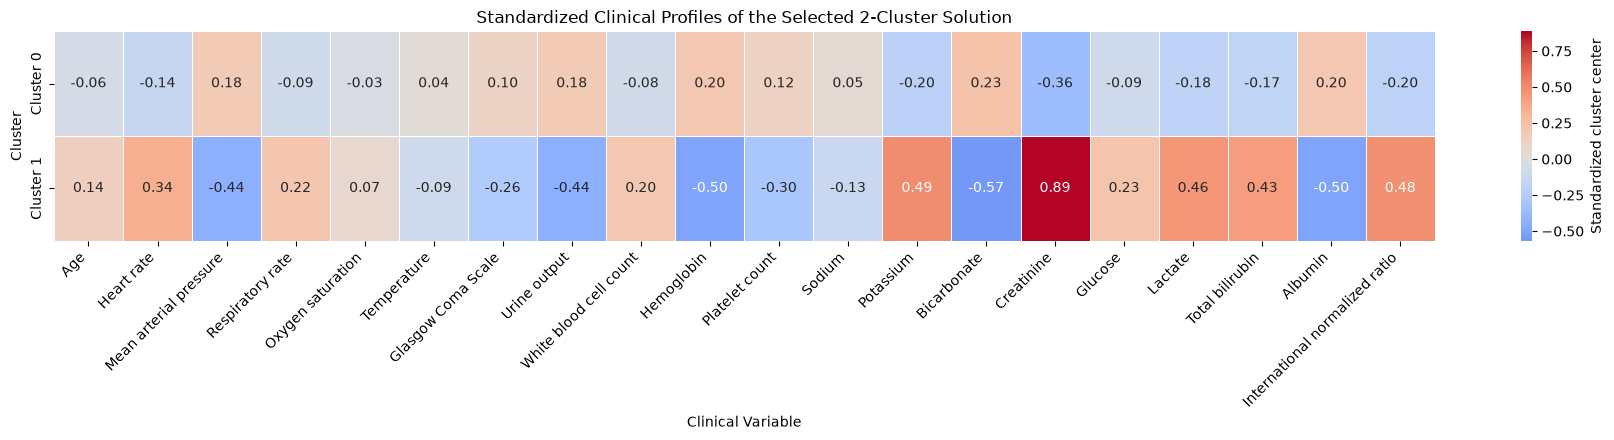

In [23]:
heatmap_data = (
    standardized_centers_clean
    .set_index("cluster")[
        FEATURES
    ]
    .copy()
)


# Use clear variable labels
heatmap_data.columns = [
    FEATURE_LABELS[feature]
    for feature in FEATURES
]


heatmap_data.index = [
    f"Cluster {cluster_number}"
    for cluster_number in heatmap_data.index
]


plt.figure(
    figsize=(
        18,
        2.5 + SELECTED_K,
    )
)


sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={
        "label": "Standardized cluster center"
    },
)


plt.title(
    f"Standardized Clinical Profiles of the "
    f"Selected {SELECTED_K}-Cluster Solution"
)

plt.xlabel(
    "Clinical Variable"
)

plt.ylabel(
    "Cluster"
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()


plt.savefig(
    PROFILE_PLOTS_DIR
    / "cluster_profile_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This is the primary required cluster-profile figure.

The heatmap contains:
- Clusters as rows
- Clinical variables as columns
- Standardized cluster centers as values

Red areas represent values above the cohort average.

Blue areas represent values below the cohort average.

### Create Strongest-Variable Figures

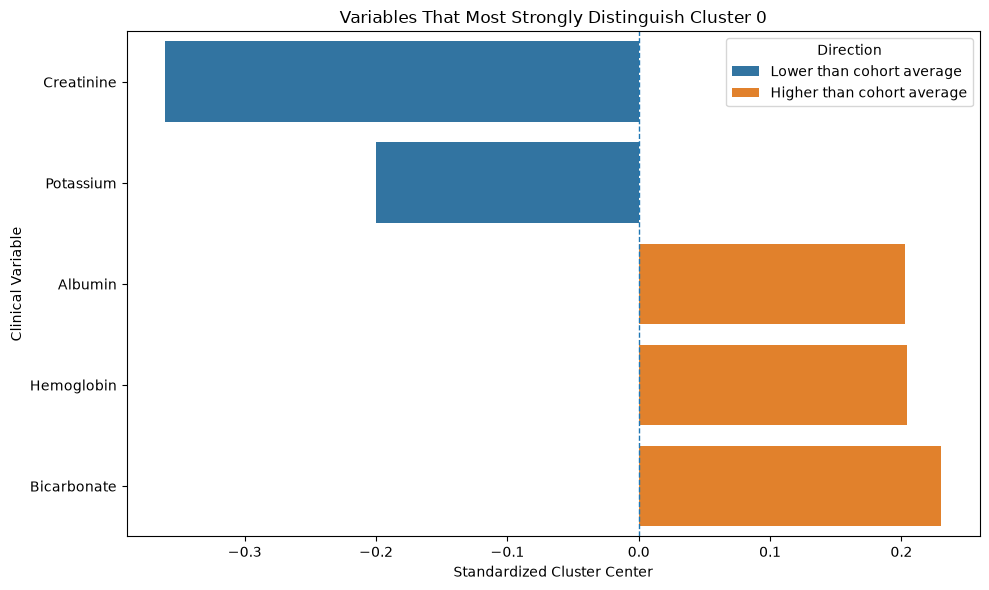

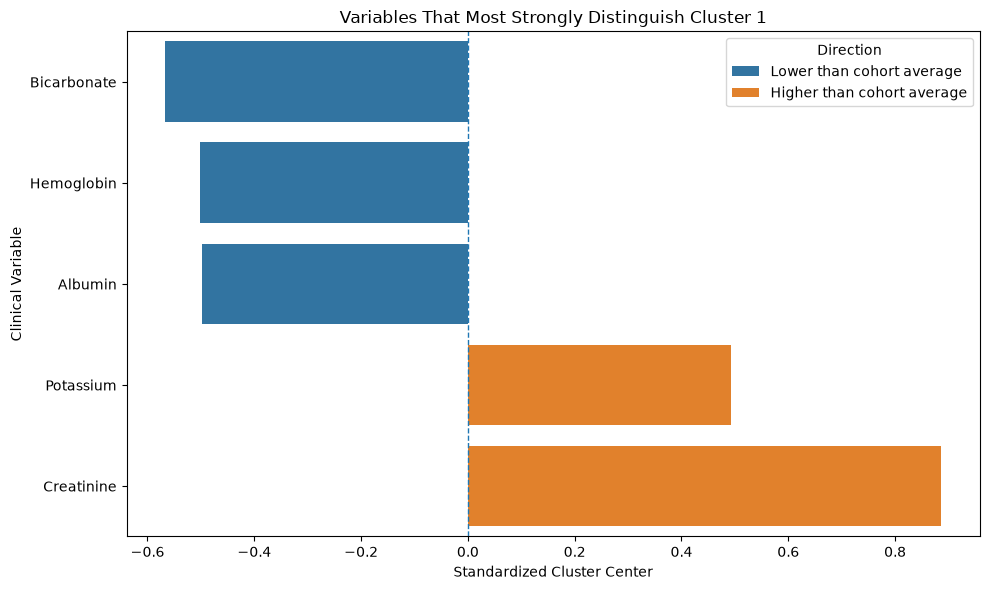

In [24]:
for cluster_number in cluster_numbers:

    current_variables = (
        cluster_distinguishing_variables[
            cluster_distinguishing_variables[
                "cluster"
            ]
            == cluster_number
        ]
        .sort_values(
            "standardized_center"
        )
    )


    plt.figure(figsize=(10, 6))


    sns.barplot(
        data=current_variables,
        x="standardized_center",
        y="variable_label",
        hue="direction",
        dodge=False,
    )


    plt.axvline(
        0,
        linestyle="--",
        linewidth=1,
    )


    plt.title(
        f"Variables That Most Strongly Distinguish "
        f"Cluster {cluster_number}"
    )

    plt.xlabel(
        "Standardized Cluster Center"
    )

    plt.ylabel(
        "Clinical Variable"
    )

    plt.legend(
        title="Direction",
        loc="best",
    )

    plt.tight_layout()


    plt.savefig(
        PROFILE_PLOTS_DIR
        / (
            f"cluster_{cluster_number}"
            "_distinguishing_variables.png"
        ),
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :
A separate bar chart is created for each cluster.

The charts show:

- The variables that most strongly define the cluster
- Whether each variable is higher or lower than the overall cohort average
- The magnitude of the standardized difference

### Select Variables for Distribution Plots

In [25]:
# Find the largest absolute cluster-center difference for every variable
variable_distinguishing_strength = (
    standardized_centers_long
    .groupby(
        [
            "variable",
            "variable_label",
        ],
        as_index=False,
    )[
        "absolute_standardized_center"
    ]
    .max()
    .sort_values(
        "absolute_standardized_center",
        ascending=False,
    )
)


boxplot_variables = (
    variable_distinguishing_strength[
        "variable"
    ]
    .head(
        NUMBER_OF_BOXPLOT_VARIABLES
    )
    .tolist()
)


print(
    "Variables selected for cluster distribution plots:"
)


for feature in boxplot_variables:

    print(
        "-",
        FEATURE_LABELS[feature],
    )

Variables selected for cluster distribution plots:
- Creatinine
- Bicarbonate
- Hemoglobin
- Albumin
- Potassium


#### Explanation :
The notebook selects the five variables with the strongest overall differences between clusters.

These variables are then displayed using cluster-level boxplots.

### Create a Reproducible Plotting Sample

In [26]:
actual_plot_sample_size = min(
    PLOT_SAMPLE_SIZE,
    len(selected_cluster_data),
)


plot_sample = selected_cluster_data.sample(
    n=actual_plot_sample_size,
    random_state=PLOT_RANDOM_SEED,
)


print(
    "Number of ICU stays used in distribution plots:",
    f"{len(plot_sample):,}",
)

Number of ICU stays used in distribution plots: 20,000


#### Explanation :
The statistical tables use all ICU stays.

The boxplots use a reproducible sample of up to 20,000 ICU stays to keep the figures clear and efficient.

### Plot the Strongest Clinical Variables by Cluster

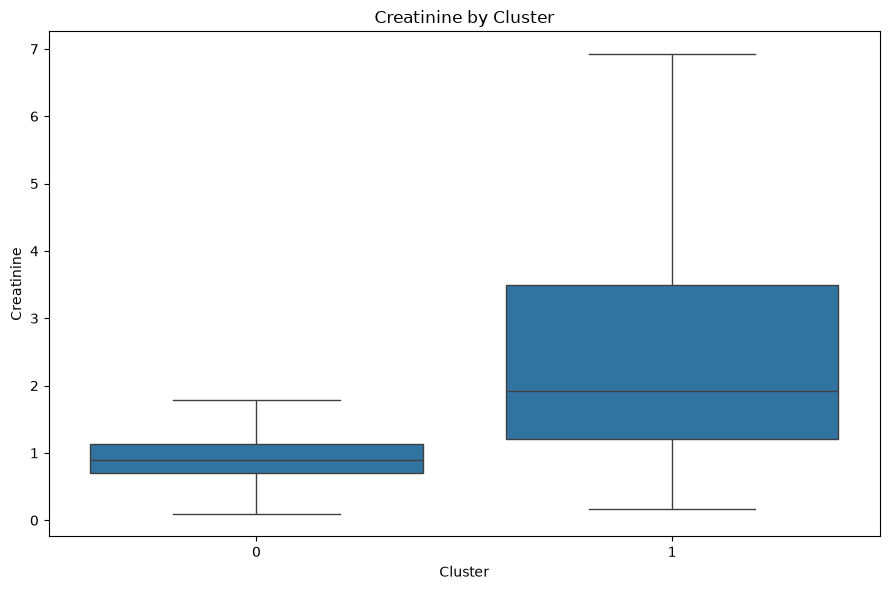

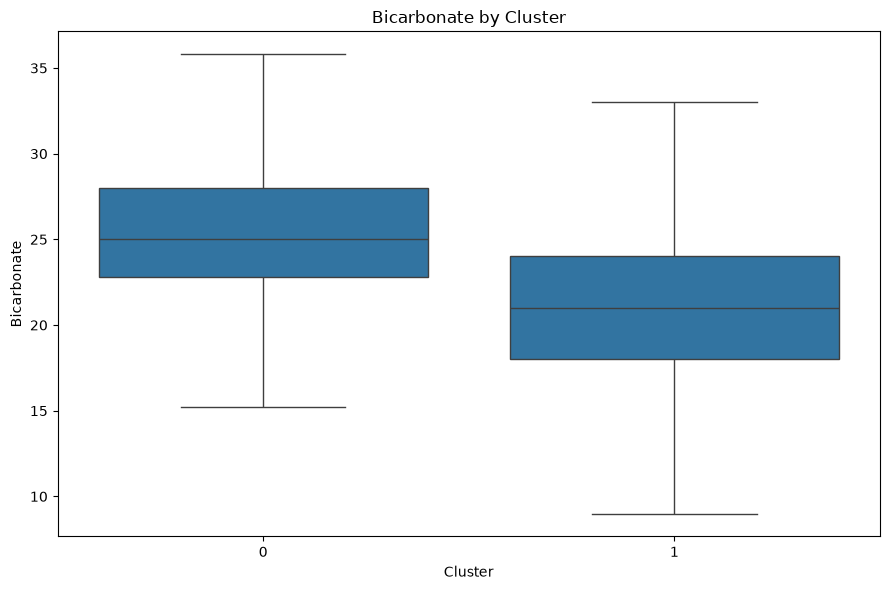

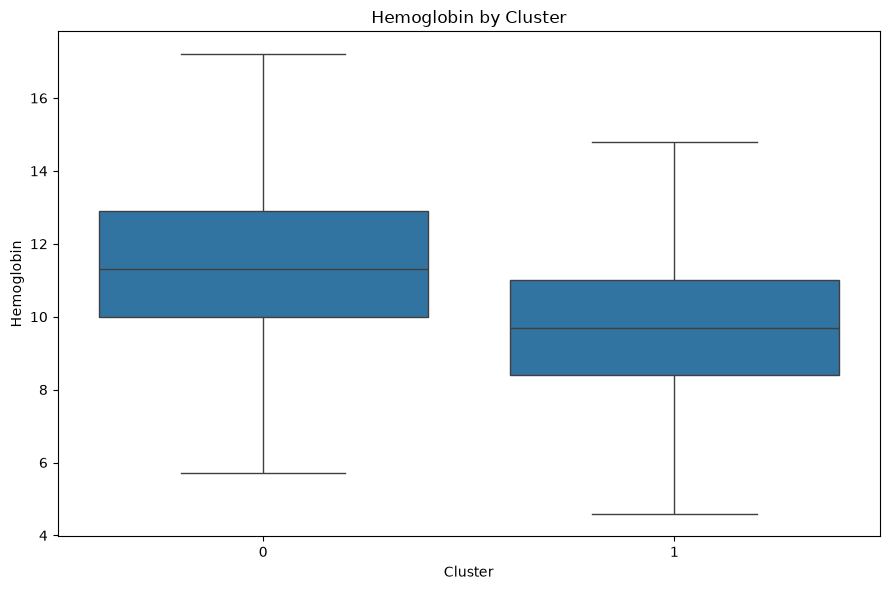

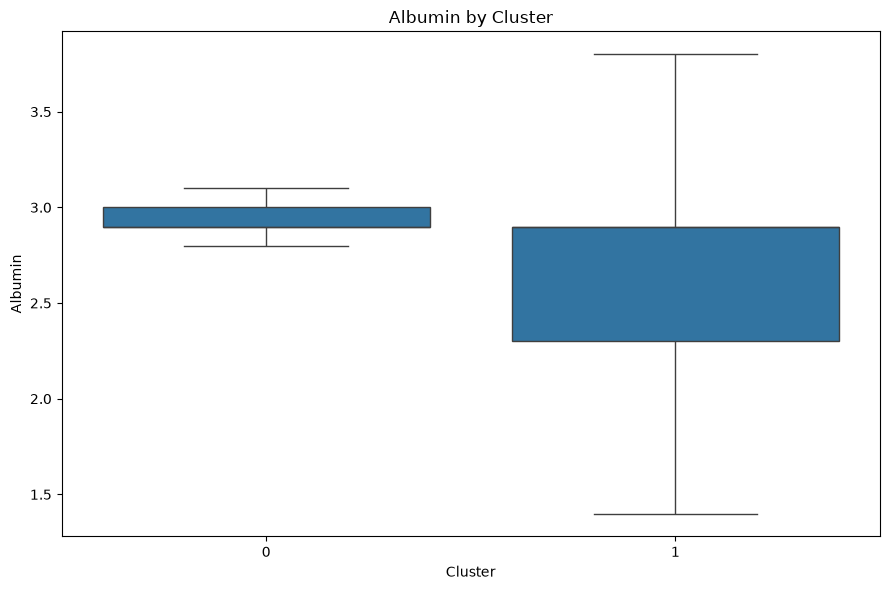

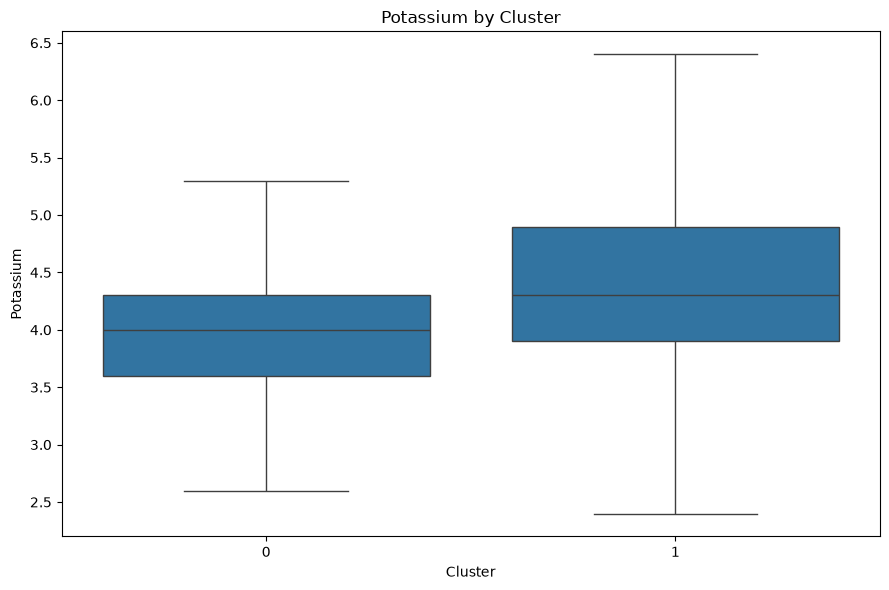

In [27]:
for feature in boxplot_variables:

    plt.figure(figsize=(9, 6))


    sns.boxplot(
        data=plot_sample,
        x="cluster",
        y=feature,
        showfliers=False,
    )


    plt.title(
        f"{FEATURE_LABELS[feature]} by Cluster"
    )

    plt.xlabel(
        "Cluster"
    )

    plt.ylabel(
        FEATURE_LABELS[feature]
    )

    plt.tight_layout()


    plt.savefig(
        DISTRIBUTION_PLOTS_DIR
        / f"{feature}_by_cluster.png",
        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

    plt.close()

#### Explanation :
These boxplots show the distributions of the strongest distinguishing variables across clusters.

Outlier points are hidden from the figure to improve readability, but the values are not removed from the statistical analysis.

### Locate the Processed Patient Table

In [28]:
def simplify_file_name(file_name):
    """
    Convert a file name into a simple lowercase form.
    """

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(file_name).lower(),
    )

#### Explanation :
This function makes the file search independent of capitalization and underscores.

For example:
```
patient.csv
Patient.csv
patient_table.csv
```
can be compared more consistently.

In [29]:
def find_processed_table(
    folder,
    expected_table_name,
):
    """
    Find a processed CSV table using a simplified name.
    """

    expected_name = simplify_file_name(
        expected_table_name
    )


    candidate_files = list(
        folder.glob("*.csv")
    )


    exact_matches = [
        file_path
        for file_path in candidate_files
        if simplify_file_name(
            file_path.stem
        )
        == expected_name
    ]


    if len(exact_matches) == 1:

        return exact_matches[0]


    if len(exact_matches) > 1:

        raise FileExistsError(
            "More than one processed file matched "
            f"'{expected_table_name}': "
            f"{exact_matches}"
        )


    return None

#### Explanation :
This function searches the processed-data folder for the patient table.

If the patient table cannot be found, the optional outcome analysis is skipped without stopping the cluster-characteristics analysis.

### Load Mortality and Length-of-Stay Outcomes

In [30]:
patient_table_path = find_processed_table(
    PROCESSED_DATA_DIR,
    "patient",
)


if patient_table_path is None:

    print(
        "The processed patient table was not found. "
        "The exploratory outcome section will be skipped."
    )

else:

    print(
        "Processed patient table found:"
    )

    print(
        patient_table_path
    )

Processed patient table found:
C:\Users\samsa\Documents\Capstone Project\Project\data\processed\patient.csv


#### Explanation :

The processed eICU patient table contains the fields needed to calculate:

- ICU mortality
- Hospital mortality
- ICU length of stay
- Hospital length of stay

This section is optional because outcome comparisons are not required for fitting or defining the clusters.

### Create a Function for Reading Available Columns

In [31]:
def read_available_columns(
    file_path,
    requested_columns,
):
    """
    Read requested columns that are available in a CSV file.
    """

    available_columns = pd.read_csv(
        file_path,
        nrows=0,
    ).columns.tolist()


    column_lookup = {
        column.lower(): column
        for column in available_columns
    }


    matched_columns = [
        column_lookup[column.lower()]
        for column in requested_columns
        if column.lower() in column_lookup
    ]


    if len(matched_columns) == 0:

        return pd.DataFrame()


    dataframe = pd.read_csv(
        file_path,
        usecols=matched_columns,
        low_memory=False,
    )


    dataframe.columns = [
        column.lower()
        for column in dataframe.columns
    ]


    return dataframe

#### Explanation :
This function reads only the outcome-related columns that are available.

It prevents the notebook from failing when a specific optional outcome field is unavailable.

### Prepare the Outcome Dataset

In [32]:
outcome_data_available = False
cluster_outcome_data = pd.DataFrame()


if patient_table_path is not None:

    requested_outcome_columns = [
        "patientUnitStayID",
        "unitDischargeStatus",
        "hospitalDischargeStatus",
        "unitDischargeOffset",
        "hospitalDischargeOffset",
    ]


    patient_outcomes = read_available_columns(
        patient_table_path,
        requested_outcome_columns,
    )


    if (
        not patient_outcomes.empty
        and ID_COLUMN
        in patient_outcomes.columns
    ):

        # Convert the ICU stay identifier to numeric
        patient_outcomes[
            ID_COLUMN
        ] = pd.to_numeric(
            patient_outcomes[
                ID_COLUMN
            ],
            errors="coerce",
        )


        patient_outcomes = (
            patient_outcomes
            .dropna(
                subset=[ID_COLUMN]
            )
            .copy()
        )


        patient_outcomes[
            ID_COLUMN
        ] = (
            patient_outcomes[
                ID_COLUMN
            ].astype("int64")
        )


        # Keep one row per ICU stay
        patient_outcomes = (
            patient_outcomes
            .drop_duplicates(
                subset=ID_COLUMN,
                keep="first",
            )
        )


        # Create ICU mortality
        if (
            "unitdischargestatus"
            in patient_outcomes.columns
        ):

            unit_status = (
                patient_outcomes[
                    "unitdischargestatus"
                ]
                .astype("string")
                .str.strip()
                .str.lower()
            )


            patient_outcomes[
                "icu_mortality"
            ] = np.where(
                unit_status.isin(
                    [
                        "expired",
                        "dead",
                        "deceased",
                    ]
                ),
                1,
                np.where(
                    unit_status.isin(
                        [
                            "alive",
                            "discharged",
                        ]
                    ),
                    0,
                    np.nan,
                ),
            )


        # Create hospital mortality
        if (
            "hospitaldischargestatus"
            in patient_outcomes.columns
        ):

            hospital_status = (
                patient_outcomes[
                    "hospitaldischargestatus"
                ]
                .astype("string")
                .str.strip()
                .str.lower()
            )


            patient_outcomes[
                "hospital_mortality"
            ] = np.where(
                hospital_status.isin(
                    [
                        "expired",
                        "dead",
                        "deceased",
                    ]
                ),
                1,
                np.where(
                    hospital_status.isin(
                        [
                            "alive",
                            "discharged",
                        ]
                    ),
                    0,
                    np.nan,
                ),
            )


        # Create ICU length of stay in days
        if (
            "unitdischargeoffset"
            in patient_outcomes.columns
        ):

            patient_outcomes[
                "unitdischargeoffset"
            ] = pd.to_numeric(
                patient_outcomes[
                    "unitdischargeoffset"
                ],
                errors="coerce",
            )


            patient_outcomes[
                "icu_length_of_stay_days"
            ] = (
                patient_outcomes[
                    "unitdischargeoffset"
                ]
                / (60 * 24)
            )


            patient_outcomes.loc[
                patient_outcomes[
                    "icu_length_of_stay_days"
                ]
                <= 0,
                "icu_length_of_stay_days",
            ] = np.nan


        # Create hospital length of stay in days
        if (
            "hospitaldischargeoffset"
            in patient_outcomes.columns
        ):

            patient_outcomes[
                "hospitaldischargeoffset"
            ] = pd.to_numeric(
                patient_outcomes[
                    "hospitaldischargeoffset"
                ],
                errors="coerce",
            )


            patient_outcomes[
                "hospital_length_of_stay_days"
            ] = (
                patient_outcomes[
                    "hospitaldischargeoffset"
                ]
                / (60 * 24)
            )


            patient_outcomes.loc[
                patient_outcomes[
                    "hospital_length_of_stay_days"
                ]
                <= 0,
                "hospital_length_of_stay_days",
            ] = np.nan


        # Keep only the created outcomes
        outcome_columns = [
            column
            for column in [
                ID_COLUMN,
                "icu_mortality",
                "hospital_mortality",
                "icu_length_of_stay_days",
                "hospital_length_of_stay_days",
            ]
            if column
            in patient_outcomes.columns
        ]


        patient_outcomes = (
            patient_outcomes[
                outcome_columns
            ]
            .copy()
        )


        cluster_outcome_data = (
            selected_cluster_data[
                [
                    ID_COLUMN,
                    "cluster",
                ]
            ]
            .merge(
                patient_outcomes,
                on=ID_COLUMN,
                how="left",
                validate="one_to_one",
            )
        )


        outcome_data_available = (
            len(outcome_columns) > 1
        )


print(
    "Outcome data available:",
    outcome_data_available,
)

Outcome data available: True


#### Explanation :
This code creates four possible outcome variables:

- ICU mortality
- Hospital mortality
- ICU length of stay in days
- Hospital length of stay in days

These outcomes were not included in the K-Means feature matrix.

Therefore, they may be compared after clustering as exploratory descriptive outcomes.

### Summarize Mortality Outcomes

In [33]:
binary_outcome_rows = []


BINARY_OUTCOME_LABELS = {
    "icu_mortality": "ICU mortality",
    "hospital_mortality": "Hospital mortality",
}


if outcome_data_available:

    available_binary_outcomes = [
        outcome
        for outcome
        in BINARY_OUTCOME_LABELS
        if outcome
        in cluster_outcome_data.columns
    ]


    for cluster_number in cluster_numbers:

        current_cluster = (
            cluster_outcome_data[
                cluster_outcome_data[
                    "cluster"
                ]
                == cluster_number
            ]
        )


        for outcome in available_binary_outcomes:

            available_values = (
                current_cluster[
                    outcome
                ]
                .dropna()
            )


            available_count = len(
                available_values
            )


            event_count = int(
                available_values.sum()
            )


            event_percent = (
                event_count
                / available_count
                * 100
                if available_count > 0
                else np.nan
            )


            binary_outcome_rows.append(
                {
                    "cluster": cluster_number,
                    "outcome": outcome,
                    "outcome_label": (
                        BINARY_OUTCOME_LABELS[
                            outcome
                        ]
                    ),
                    "available_count": (
                        available_count
                    ),
                    "event_count": (
                        event_count
                    ),
                    "event_percent": (
                        event_percent
                    ),
                }
            )


binary_outcome_summary = pd.DataFrame(
    binary_outcome_rows
)


if not binary_outcome_summary.empty:

    binary_outcome_summary.to_csv(
        RESULTS_DIR
        / "cluster_mortality_summary.csv",
        index=False,
    )


binary_outcome_summary

,cluster,outcome,outcome_label,available_count,event_count,event_percent
0,0,icu_mortality,ICU mortality,87827,2360,2.687101
1,0,hospital_mortality,Hospital mortality,87079,4636,5.323901
2,1,icu_mortality,ICU mortality,35566,4296,12.078952
3,1,hospital_mortality,Hospital mortality,35213,6822,19.373527


#### Explanation :
For mortality outcomes, the table reports:

- Number of ICU stays with an available outcome
- Number of deaths
- Mortality percentage

The comparison is descriptive. No causal conclusion should be made from these percentages.

### Summarize Length-of-Stay Outcomes

In [34]:
continuous_outcome_rows = []


CONTINUOUS_OUTCOME_LABELS = {
    "icu_length_of_stay_days": (
        "ICU length of stay, days"
    ),
    "hospital_length_of_stay_days": (
        "Hospital length of stay, days"
    ),
}


if outcome_data_available:

    available_continuous_outcomes = [
        outcome
        for outcome
        in CONTINUOUS_OUTCOME_LABELS
        if outcome
        in cluster_outcome_data.columns
    ]


    for cluster_number in cluster_numbers:

        current_cluster = (
            cluster_outcome_data[
                cluster_outcome_data[
                    "cluster"
                ]
                == cluster_number
            ]
        )


        for outcome in available_continuous_outcomes:

            outcome_values = (
                current_cluster[
                    outcome
                ]
                .dropna()
            )


            first_quartile = (
                outcome_values.quantile(0.25)
            )

            median_value = (
                outcome_values.median()
            )

            third_quartile = (
                outcome_values.quantile(0.75)
            )


            continuous_outcome_rows.append(
                {
                    "cluster": cluster_number,
                    "outcome": outcome,
                    "outcome_label": (
                        CONTINUOUS_OUTCOME_LABELS[
                            outcome
                        ]
                    ),
                    "available_count": (
                        outcome_values.count()
                    ),
                    "mean": (
                        outcome_values.mean()
                    ),
                    "standard_deviation": (
                        outcome_values.std()
                    ),
                    "median": (
                        median_value
                    ),
                    "first_quartile": (
                        first_quartile
                    ),
                    "third_quartile": (
                        third_quartile
                    ),
                    "interquartile_range": (
                        third_quartile
                        - first_quartile
                    ),
                }
            )


continuous_outcome_summary = pd.DataFrame(
    continuous_outcome_rows
)


if not continuous_outcome_summary.empty:

    continuous_outcome_summary.to_csv(
        RESULTS_DIR
        / "cluster_length_of_stay_summary.csv",
        index=False,
    )


continuous_outcome_summary

,cluster,outcome,outcome_label,available_count,mean,standard_deviation,median,first_quartile,third_quartile,interquartile_range
0,0,icu_length_of_stay_days,"ICU length of stay, days",87828,3.483471,4.603954,2.152778,1.532639,3.798611,2.265972
1,0,hospital_length_of_stay_days,"Hospital length of stay, days",87825,7.503491,9.326146,5.212500,3.168750,8.809722,5.640972
2,1,icu_length_of_stay_days,"ICU length of stay, days",35572,4.716713,5.541937,2.970833,1.860417,5.347917,3.487500
3,1,hospital_length_of_stay_days,"Hospital length of stay, days",35568,10.357131,11.781487,7.330903,4.272049,12.725694,8.453646


#### Explanation :
Length of stay is summarized using:
- Mean
- Standard deviation
- Median
- Interquartile range

THe median and interquartile range are usually more appropriate because length-of-stay distributions are commonly right-skewed.

### Create the Exploratory Outcome Table

In [35]:
outcome_table_rows = []


if not binary_outcome_summary.empty:

    for outcome in (
        binary_outcome_summary[
            "outcome"
        ].unique()
    ):

        outcome_label = (
            binary_outcome_summary.loc[
                binary_outcome_summary[
                    "outcome"
                ]
                == outcome,
                "outcome_label",
            ]
            .iloc[0]
        )


        outcome_row = {
            "Outcome": (
                f"{outcome_label}, "
                "events/available (%)"
            )
        }


        for cluster_number in cluster_numbers:

            current_result = (
                binary_outcome_summary[
                    (
                        binary_outcome_summary[
                            "cluster"
                        ]
                        == cluster_number
                    )
                    &
                    (
                        binary_outcome_summary[
                            "outcome"
                        ]
                        == outcome
                    )
                ]
            )


            if current_result.empty:

                formatted_value = "Not available"

            else:

                current_result = (
                    current_result.iloc[0]
                )


                formatted_value = (
                    f"{int(current_result['event_count']):,}/"
                    f"{int(current_result['available_count']):,} "
                    f"({current_result['event_percent']:.2f}%)"
                )


            outcome_row[
                f"Cluster {cluster_number}"
            ] = formatted_value


        outcome_table_rows.append(
            outcome_row
        )


if not continuous_outcome_summary.empty:

    for outcome in (
        continuous_outcome_summary[
            "outcome"
        ].unique()
    ):

        outcome_label = (
            continuous_outcome_summary.loc[
                continuous_outcome_summary[
                    "outcome"
                ]
                == outcome,
                "outcome_label",
            ]
            .iloc[0]
        )


        outcome_row = {
            "Outcome": (
                f"{outcome_label}, "
                "median [IQR]"
            )
        }


        for cluster_number in cluster_numbers:

            current_result = (
                continuous_outcome_summary[
                    (
                        continuous_outcome_summary[
                            "cluster"
                        ]
                        == cluster_number
                    )
                    &
                    (
                        continuous_outcome_summary[
                            "outcome"
                        ]
                        == outcome
                    )
                ]
            )


            if current_result.empty:

                formatted_value = "Not available"

            else:

                current_result = (
                    current_result.iloc[0]
                )


                formatted_value = format_median_iqr(
                    current_result["median"],
                    current_result[
                        "first_quartile"
                    ],
                    current_result[
                        "third_quartile"
                    ],
                )


            outcome_row[
                f"Cluster {cluster_number}"
            ] = formatted_value


        outcome_table_rows.append(
            outcome_row
        )


cluster_outcome_table = pd.DataFrame(
    outcome_table_rows
)


if not cluster_outcome_table.empty:

    cluster_outcome_table.to_csv(
        RESULTS_DIR
        / "cluster_outcome_summary.csv",
        index=False,
    )


cluster_outcome_table

,Outcome,Cluster 0,Cluster 1
0,"ICU mortality, events/available (%)","2,360/87,827 (2.69%)","4,296/35,566 (12.08%)"
1,"Hospital mortality, events/available (%)","4,636/87,079 (5.32%)","6,822/35,213 (19.37%)"
2,"ICU length of stay, days, median [IQR]",2.15 [1.53–3.80],2.97 [1.86–5.35]
3,"Hospital length of stay, days, median [IQR]",5.21 [3.17–8.81],7.33 [4.27–12.73]


#### Explanation :
This creates one presentation-ready table containing:

- ICU mortality
- Hospital mortality
- ICU length of stay
- Hospital length of stay

The table should be labeled as exploratory and descriptive.

### Plot Mortality Percentages

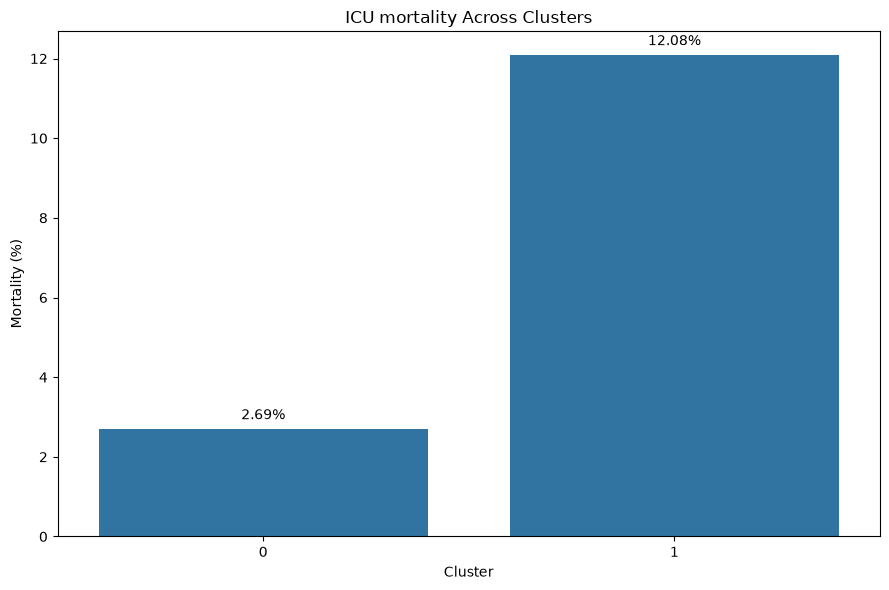

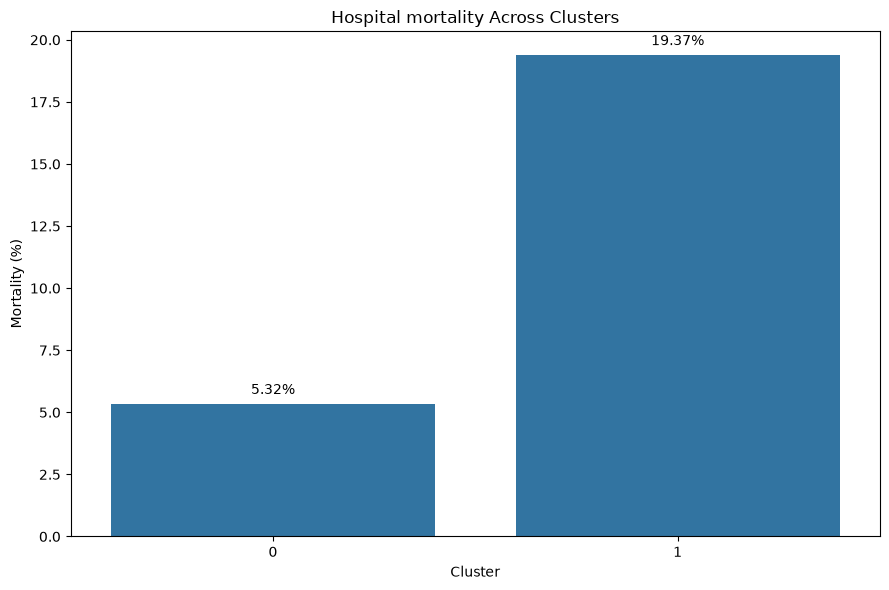

In [36]:
if not binary_outcome_summary.empty:

    for outcome in (
        binary_outcome_summary[
            "outcome"
        ].unique()
    ):

        current_outcome = (
            binary_outcome_summary[
                binary_outcome_summary[
                    "outcome"
                ]
                == outcome
            ]
        )


        outcome_label = (
            current_outcome[
                "outcome_label"
            ].iloc[0]
        )


        plt.figure(figsize=(9, 6))


        outcome_plot = sns.barplot(
            data=current_outcome,
            x="cluster",
            y="event_percent",
        )


        for bar, percent in zip(
            outcome_plot.patches,
            current_outcome[
                "event_percent"
            ],
        ):

            outcome_plot.annotate(
                f"{percent:.2f}%",
                (
                    bar.get_x()
                    + bar.get_width() / 2,
                    bar.get_height(),
                ),
                ha="center",
                va="bottom",
                xytext=(0, 5),
                textcoords="offset points",
            )


        plt.title(
            f"{outcome_label} Across Clusters"
        )

        plt.xlabel(
            "Cluster"
        )

        plt.ylabel(
            "Mortality (%)"
        )

        plt.tight_layout()


        plt.savefig(
            OUTCOME_PLOTS_DIR
            / f"{outcome}_by_cluster.png",
            dpi=300,
            bbox_inches="tight",
        )


        plt.show()

        plt.close()

#### Explanation :
These bar charts show exploratory mortality percentages across clusters.

Differences should not be interpreted as proof that cluster membership causes mortality.

### Plot Length of Stay by Cluster

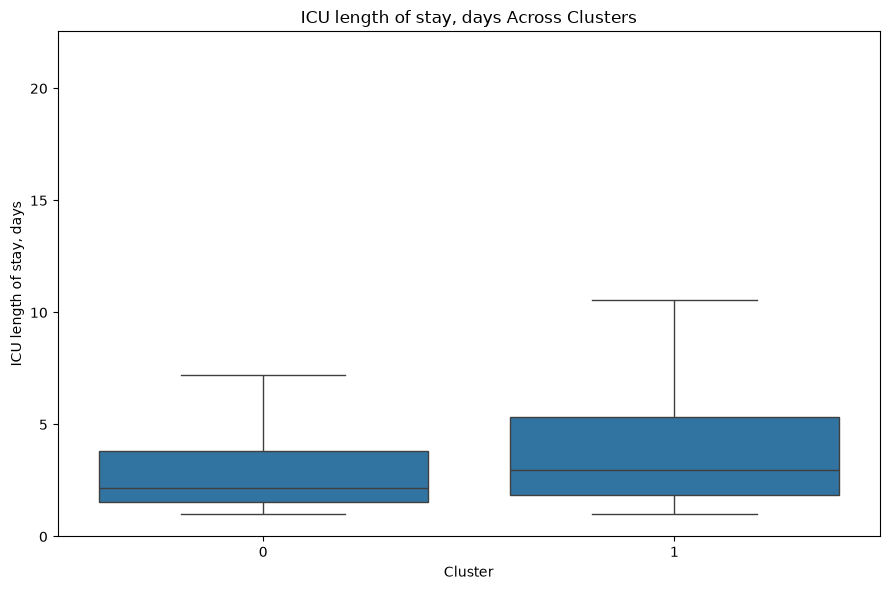

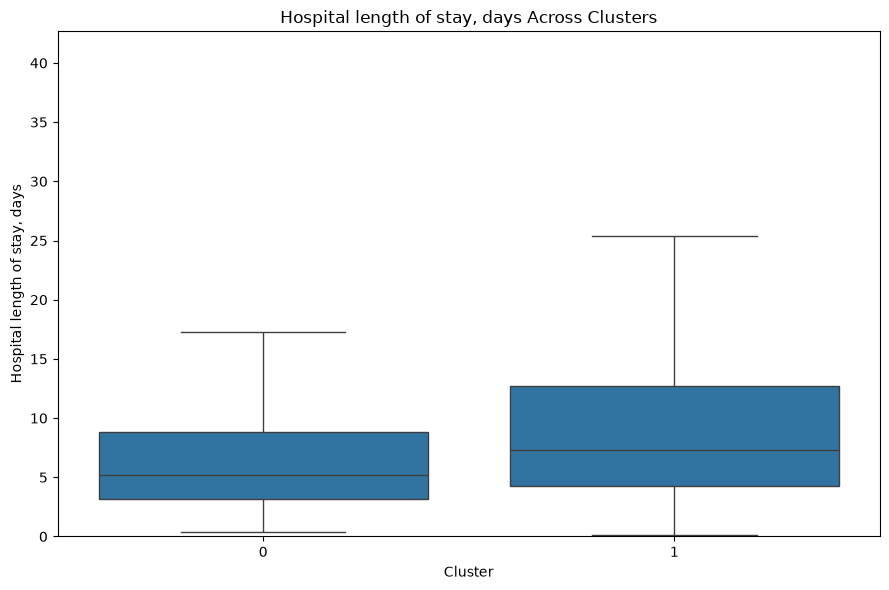

In [37]:
if (
    outcome_data_available
    and not continuous_outcome_summary.empty
):

    for outcome in (
        continuous_outcome_summary[
            "outcome"
        ].unique()
    ):

        plot_data = cluster_outcome_data[
            [
                "cluster",
                outcome,
            ]
        ].dropna()


        # Limit only the displayed y-axis to reduce the visual effect
        # of very long stays. The statistical table still uses all values.
        upper_plot_limit = (
            plot_data[
                outcome
            ].quantile(0.99)
        )


        outcome_label = (
            CONTINUOUS_OUTCOME_LABELS[
                outcome
            ]
        )


        plt.figure(figsize=(9, 6))


        sns.boxplot(
            data=plot_data,
            x="cluster",
            y=outcome,
            showfliers=False,
        )


        plt.ylim(
            0,
            upper_plot_limit,
        )


        plt.title(
            f"{outcome_label} Across Clusters"
        )

        plt.xlabel(
            "Cluster"
        )

        plt.ylabel(
            outcome_label
        )

        plt.tight_layout()


        plt.savefig(
            OUTCOME_PLOTS_DIR
            / f"{outcome}_by_cluster.png",
            dpi=300,
            bbox_inches="tight",
        )


        plt.show()

        plt.close()

#### Explanation :
These boxplots compare length of stay across clusters.

The y-axis is limited to the 99th percentile for readability. The underlying statistical summaries continue to use all available observations.

### Save the Outcome-Linked Dataset

In [38]:
if outcome_data_available:

    cluster_outcome_data.to_csv(
        RESULTS_DIR
        / "cluster_outcome_dataset.csv",
        index=False,
    )


    print(
        "Outcome-linked cluster dataset saved to:"
    )

    print(
        RESULTS_DIR
        / "cluster_outcome_dataset.csv"
    )

Outcome-linked cluster dataset saved to:
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics\cluster_outcome_dataset.csv


#### Explanation :
This dataset connects each cluster assignment with the available mortality and length-of-stay outcomes.

It can support later exploratory clinical validation.

### Create a Concise Cluster Summary

In [39]:
cluster_summary_rows = []


for cluster_number in cluster_numbers:

    current_size = (
        cluster_size_summary[
            cluster_size_summary[
                "cluster"
            ]
            == cluster_number
        ]
        .iloc[0]
    )


    interpretation = (
        cluster_interpretations.loc[
            cluster_interpretations[
                "cluster"
            ]
            == cluster_number,
            "brief_interpretation",
        ]
        .iloc[0]
    )


    top_variables = (
        cluster_distinguishing_variables[
            cluster_distinguishing_variables[
                "cluster"
            ]
            == cluster_number
        ][
            "variable_label"
        ]
        .tolist()
    )


    cluster_summary_rows.append(
        {
            "selected_k": SELECTED_K,
            "cluster": cluster_number,
            "icu_stay_count": int(
                current_size[
                    "icu_stay_count"
                ]
            ),
            "icu_stay_percent": (
                current_size[
                    "icu_stay_percent"
                ]
            ),
            "strongest_variables": (
                ", ".join(top_variables)
            ),
            "brief_interpretation": (
                interpretation
            ),
        }
    )


concise_cluster_summary = pd.DataFrame(
    cluster_summary_rows
)


concise_cluster_summary.to_csv(
    RESULTS_DIR
    / "concise_cluster_summary.csv",
    index=False,
)


concise_cluster_summary

,selected_k,cluster,icu_stay_count,icu_stay_percent,strongest_variables,brief_interpretation
0,2,0,87828,71.17342,"Creatinine, Bicarbonate, Hemoglobin, Albumin, Potassium","This cluster was characterized by higher bicarbonate, higher hemoglobin, and higher albumin; lower creatinine and lower potassium compared with the overall study cohort."
1,2,1,35572,28.82658,"Creatinine, Bicarbonate, Hemoglobin, Albumin, Potassium","This cluster was characterized by higher creatinine and higher potassium; lower bicarbonate, lower hemoglobin, and lower albumin compared with the overall study cohort."


#### Explanation :
This table provides a short summary for each cluster:
- Cluster size
- Cluster percentage
- Strongest distinguishing variables
- Brief descriptive interpretation

It is useful for documentation and presentations.

### Perform Final Checks

In [40]:
# Confirm one row per ICU stay
assert (
    selected_cluster_data[
        ID_COLUMN
    ].duplicated().sum()
    == 0
), (
    "Duplicate ICU stay identifiers exist in "
    "the selected cluster dataset."
)


# Confirm all expected clusters are represented
assert (
    selected_cluster_data[
        "cluster"
    ].nunique()
    == SELECTED_K
), (
    "The merged dataset does not contain the "
    "expected number of clusters."
)


# Confirm cluster-size counts sum to the total cohort
assert (
    cluster_size_summary[
        "icu_stay_count"
    ].sum()
    == len(selected_cluster_data)
), (
    "Cluster-size counts do not sum to the total cohort."
)


# Confirm percentages sum to approximately 100%
assert np.isclose(
    cluster_size_summary[
        "icu_stay_percent"
    ].sum(),
    100,
), (
    "Cluster percentages do not sum to 100%."
)


# Confirm every feature was summarized
assert (
    cluster_characteristics_long[
        "variable"
    ].nunique()
    == len(FEATURES)
), (
    "One or more clinical variables were not summarized."
)


# Confirm every cluster has distinguishing variables
assert (
    cluster_distinguishing_variables[
        "cluster"
    ].nunique()
    == SELECTED_K
), (
    "One or more clusters are missing distinguishing variables."
)


print("=" * 80)
print("FINAL CHECKS PASSED")
print("=" * 80)

print(
    f"Selected preliminary k   : "
    f"{SELECTED_K}"
)

print(
    f"Number of ICU stays      : "
    f"{len(selected_cluster_data):,}"
)

print(
    f"Number of clusters       : "
    f"{SELECTED_K}"
)

print(
    f"Clinical variables       : "
    f"{len(FEATURES)}"
)

print("=" * 80)

FINAL CHECKS PASSED
Selected preliminary k   : 2
Number of ICU stays      : 123,400
Number of clusters       : 2
Clinical variables       : 20


#### Explanation :
The final checks confirm that:
- Every ICU stay appears only once
- All selected clusters are represented
- Cluster counts match the total cohort
- Cluster percentages sum to 100%
- All 20 variables were summarized
- Every cluster has a list of distinguishing variables

### Display the Main Deliverables

In [41]:
print("=" * 85)
print("MAIN CLUSTER CHARACTERIZATION OUTPUTS")
print("=" * 85)


print("\nPrimary cluster-characteristics table")
print("-" * 85)

print(
    RESULTS_DIR
    / "cluster_characteristics_table.csv"
)


print("\nDetailed clinical summary")
print("-" * 85)

print(
    RESULTS_DIR
    / "cluster_characteristics_long_format.csv"
)


print("\nStrongest distinguishing variables")
print("-" * 85)

print(
    RESULTS_DIR
    / "cluster_distinguishing_variables.csv"
)


print("\nCluster interpretations")
print("-" * 85)

print(
    RESULTS_DIR
    / "cluster_interpretations.csv"
)


print("\nConcise cluster summary")
print("-" * 85)

print(
    RESULTS_DIR
    / "concise_cluster_summary.csv"
)


if outcome_data_available:

    print("\nExploratory outcome summary")
    print("-" * 85)

    print(
        RESULTS_DIR
        / "cluster_outcome_summary.csv"
    )


print("\nMain cluster-profile figure")
print("-" * 85)

print(
    PROFILE_PLOTS_DIR
    / "cluster_profile_heatmap.png"
)


print("=" * 85)

MAIN CLUSTER CHARACTERIZATION OUTPUTS

Primary cluster-characteristics table
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics\cluster_characteristics_table.csv

Detailed clinical summary
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics\cluster_characteristics_long_format.csv

Strongest distinguishing variables
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics\cluster_distinguishing_variables.csv

Cluster interpretations
-------------------------------------------------------------------------------------
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_characteristics\cluster_interpretations.csv

Concise cluster summary

#### Explanation :
This final cell displays the location of the most important tables and figures.

### Display the Final Cluster Characteristics Table


In [42]:
cluster_characteristics_table

,Characteristic,Cluster 0,Cluster 1
0,"ICU stays, n (%)","87,828 (71.17%)","35,572 (28.83%)"
1,"Age, median [IQR]",65.00 [53.00–76.00],68.00 [57.00–78.00]
2,"Heart rate, median [IQR]",82.36 [72.12–93.03],90.09 [78.98–102.72]
3,"Mean arterial pressure, median [IQR]",81.56 [73.73–91.30],73.34 [66.80–81.24]
4,"Respiratory rate, median [IQR]",18.98 [16.44–21.25],19.62 [17.35–23.39]
5,"Oxygen saturation, median [IQR]",97.03 [95.54–98.33],97.36 [95.82–98.75]
6,"Temperature, median [IQR]",37.12 [37.12–37.12],37.12 [37.12–37.12]
7,"Glasgow Coma Scale, median [IQR]",14.00 [13.00–15.00],14.00 [9.00–15.00]
8,"Urine output, median [IQR]",1400.00 [1160.00–2135.25],1400.00 [550.00–1400.00]
9,"White blood cell count, median [IQR]",10.70 [7.80–13.60],11.90 [8.50–17.60]


#### Explanation :

This is the main table to include in the report or presentation.

It contains the cluster sizes and the median with interquartile range for all 20 clinical variables.

### Display the Concise Cluster Summary

In [43]:
concise_cluster_summary

,selected_k,cluster,icu_stay_count,icu_stay_percent,strongest_variables,brief_interpretation
0,2,0,87828,71.17342,"Creatinine, Bicarbonate, Hemoglobin, Albumin, Potassium","This cluster was characterized by higher bicarbonate, higher hemoglobin, and higher albumin; lower creatinine and lower potassium compared with the overall study cohort."
1,2,1,35572,28.82658,"Creatinine, Bicarbonate, Hemoglobin, Albumin, Potassium","This cluster was characterized by higher creatinine and higher potassium; lower bicarbonate, lower hemoglobin, and lower albumin compared with the overall study cohort."


#### Explanation :

This table gives a compact interpretation of each cluster and the variables that distinguish it most strongly.

### Display the Exploratory Outcome Summary

In [44]:
if cluster_outcome_table.empty:

    print(
        "No exploratory outcome summary was created."
    )

else:

    display(
        cluster_outcome_table
    )

,Outcome,Cluster 0,Cluster 1
0,"ICU mortality, events/available (%)","2,360/87,827 (2.69%)","4,296/35,566 (12.08%)"
1,"Hospital mortality, events/available (%)","4,636/87,079 (5.32%)","6,822/35,213 (19.37%)"
2,"ICU length of stay, days, median [IQR]",2.15 [1.53–3.80],2.97 [1.86–5.35]
3,"Hospital length of stay, days, median [IQR]",5.21 [3.17–8.81],7.33 [4.27–12.73]


#### Explanation :
This displays the mortality and length-of-stay comparisons when the necessary outcome fields were available in the processed patient table.

These results should be described as exploratory rather than confirmatory.